[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...


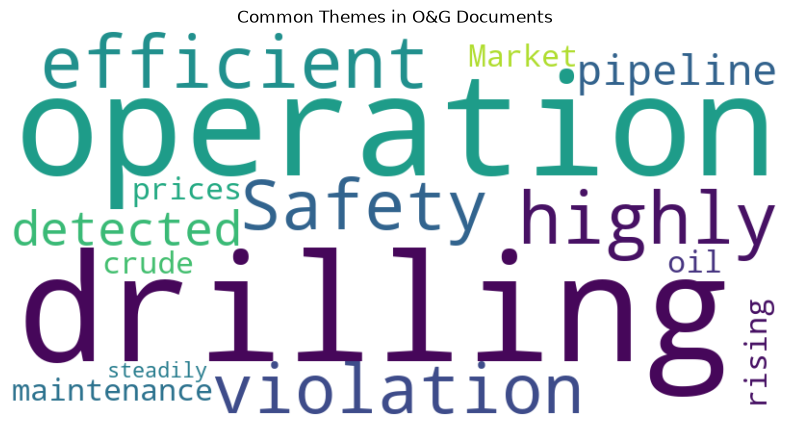

                                                text sentiment  \
0       The drilling operation was highly efficient.  Positive   
1  Safety violation detected during pipeline main...  Negative   
2   Market prices for crude oil are rising steadily.  Negative   

   sentiment_score  
0           0.4754  
1          -0.1027  
2          -0.5719  


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

# Example O&G Data
data = {'doc_id': [1, 2, 3],
        'text': ['The drilling operation was highly efficient.',
                 'Safety violation detected during pipeline maintenance.',
                 'Market prices for crude oil are rising steadily.']}
df = pd.DataFrame(data)

# 1. Sentiment Analysis
analyzer = SentimentIntensityAnalyzer()
df['sentiment_score'] = df['text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
df['sentiment'] = df['sentiment_score'].apply(lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral'))

# 2. Word Cloud Visualization
all_text = " ".join(df['text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Common Themes in O&G Documents")
plt.show()

print(df[['text', 'sentiment', 'sentiment_score']])

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd

# Example labeled data for classification
# Categories: 0: Operational, 1: Safety, 2: Market
df_class = pd.DataFrame({
    'text': ['Drilling efficiency', 'Pipeline leak safety', 'Oil price surge',
             'Rig maintenance', 'Hazardous site spill', 'Brent crude forecast'],
    'category': [0, 1, 2, 0, 1, 2]
})

# 1. TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words='english')
X = tfidf.fit_transform(df_class['text'])

feature_names = tfidf.get_feature_names_out()

tf_idf_matrix = pd.DataFrame(X.toarray(), columns=feature_names)
print(tf_idf_matrix)

y = df_class['category']

# 2. Train Classification Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestClassifier()
model.fit(X_train, y_train)

# 3. Evaluation
preds = model.predict(X_test)
print(classification_report(y_test, preds, target_names=['Operational', 'Safety', 'Market']))


     brent    crude  drilling  efficiency  forecast  hazardous     leak  \
0  0.00000  0.00000  0.707107    0.707107   0.00000    0.00000  0.00000   
1  0.00000  0.00000  0.000000    0.000000   0.00000    0.00000  0.57735   
2  0.00000  0.00000  0.000000    0.000000   0.00000    0.00000  0.00000   
3  0.00000  0.00000  0.000000    0.000000   0.00000    0.00000  0.00000   
4  0.00000  0.00000  0.000000    0.000000   0.00000    0.57735  0.00000   
5  0.57735  0.57735  0.000000    0.000000   0.57735    0.00000  0.00000   

   maintenance      oil  pipeline    price       rig   safety     site  \
0     0.000000  0.00000   0.00000  0.00000  0.000000  0.00000  0.00000   
1     0.000000  0.00000   0.57735  0.00000  0.000000  0.57735  0.00000   
2     0.000000  0.57735   0.00000  0.57735  0.000000  0.00000  0.00000   
3     0.707107  0.00000   0.00000  0.00000  0.707107  0.00000  0.00000   
4     0.000000  0.00000   0.00000  0.00000  0.000000  0.00000  0.57735   
5     0.000000  0.00000   0.00

c:\Users\USER\Control\day1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\Control\day1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\Control\day1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USE